![alt text](image-2.png)

## 4. 파이썬 코딩으로 확인하는 다중 선형 회귀

### 1.환경 준비

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 2. 데이터 준비

In [2]:
#공부 시간 x1과 과외 시간 x2, 그성적 y의 넘파이 배열을 만듭니다. 
x1 = np.array([2, 4, 6, 8])
x2 = np.array([0, 4, 2, 3])
y = np.array([81, 93, 91, 97]) 

### 3. 데이터 분포 확인

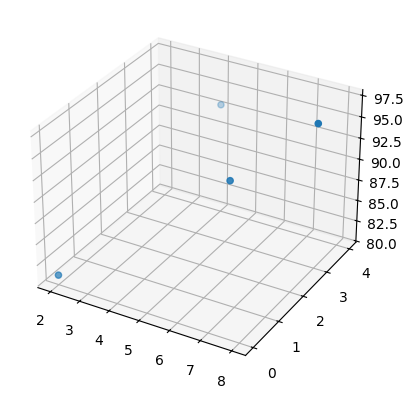

In [3]:
# 데이터의 분포를 그래프로 나타냅니다.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(x1, x2, y)
plt.show()

### 4. 실행을 위한 변수 설정

In [4]:
# 기울기 a와 절편 b의 값을 초기화합니다.
a1 = 0
a2 = 0
b = 0

#학습률을 정합니다.
lr = 0.01 

#몇 번 반복될지를 설정합니다.
epochs = 2001 

### 5. 경사 하강법

In [5]:
# x 값이 총 몇 개인지 셉니다. x1과 x2의 수가 같으므로 x1만 세겠습니다. 
n=len(x1)

#경사 하강법을 시작합니다.
for i in range(epochs):                  # epoch 수 만큼 반복
    
    y_pred = a1 * x1 + a2 * x2 + b       #예측 값을 구하는 식을 세웁니다
    error = y - y_pred                   #실제 값과 비교한 오차를 error로 놓습니다.
    
    a1_diff = (2/n) * sum(-x1 * (error)) # 오차함수를 a1로 편미분한 값입니다. 
    a2_diff = (2/n) * sum(-x2 * (error)) # 오차함수를 a2로 편미분한 값입니다. 
    b_diff = (2/n) * sum(-(error))       # 오차함수를 b로 편미분한 값입니다. 
    
    a1 = a1 - lr * a1_diff  # 학습률을 곱해 기존의 a1 값을 업데이트합니다.
    a2 = a2 - lr * a2_diff  # 학습률을 곱해 기존의 a2 값을 업데이트합니다.
    b = b - lr * b_diff     # 학습률을 곱해 기존의 b 값을 업데이트합니다.
    
    if i % 100 == 0:        # 100번 반복될 때마다 현재의 a1, a2, b 값을 출력합니다.
        print("epoch=%.f, 기울기1=%.04f, 기울기2=%.04f, 절편=%.04f" % (i, a1, a2, b))
        

epoch=0, 기울기1=9.2800, 기울기2=4.2250, 절편=1.8100
epoch=100, 기울기1=9.5110, 기울기2=5.0270, 절편=22.9205
epoch=200, 기울기1=7.3238, 기울기2=4.2950, 절편=37.8751
epoch=300, 기울기1=5.7381, 기울기2=3.7489, 절편=48.7589
epoch=400, 기울기1=4.5844, 기울기2=3.3507, 절편=56.6800
epoch=500, 기울기1=3.7447, 기울기2=3.0608, 절편=62.4448
epoch=600, 기울기1=3.1337, 기울기2=2.8498, 절편=66.6404
epoch=700, 기울기1=2.6890, 기울기2=2.6962, 절편=69.6938
epoch=800, 기울기1=2.3653, 기울기2=2.5845, 절편=71.9160
epoch=900, 기울기1=2.1297, 기울기2=2.5032, 절편=73.5333
epoch=1000, 기울기1=1.9583, 기울기2=2.4440, 절편=74.7103
epoch=1100, 기울기1=1.8336, 기울기2=2.4009, 절편=75.5670
epoch=1200, 기울기1=1.7428, 기울기2=2.3695, 절편=76.1904
epoch=1300, 기울기1=1.6767, 기울기2=2.3467, 절편=76.6441
epoch=1400, 기울기1=1.6286, 기울기2=2.3301, 절편=76.9743
epoch=1500, 기울기1=1.5936, 기울기2=2.3180, 절편=77.2146
epoch=1600, 기울기1=1.5681, 기울기2=2.3092, 절편=77.3895
epoch=1700, 기울기1=1.5496, 기울기2=2.3028, 절편=77.5168
epoch=1800, 기울기1=1.5361, 기울기2=2.2982, 절편=77.6095
epoch=1900, 기울기1=1.5263, 기울기2=2.2948, 절편=77.6769
epoch=2000, 기울기1=1.5191, 기울기2=2.2

In [6]:
#실제 점수와 예측 된 점수를 출력합니다.
print("실제 점수:", y)
print("예측 점수:", y_pred)

실제 점수: [81 93 91 97]
예측 점수: [80.76387645 92.97153922 91.42520875 96.7558749 ]


## 5-1. 텐서플로에서 실행하는 선형 회귀 모델

### 1.환경 준비

In [7]:
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [8]:
x = np.array([2, 4, 6, 8])
y = np.array([81, 93, 91, 97]) 

### 3. 모델 실행

In [9]:
model = Sequential()

# 출력 값, 입력 변수, 분석 방법에 맞게끔 모델을 설정합니다. 
model.add(Dense(1, input_dim=1, activation='linear'))

# 오차 수정을 위해 경사 하강법(sgd)을, 오차의 정도를 판단하기 위해 평균 제곱 오차(mse)를 사용합니다. 
model.compile(optimizer='sgd', loss='mse')

# 오차를 최소화하는 과정을 2000번 반복합니다.
model.fit(x, y, epochs=2000)

Epoch 1/2000


c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 9760.2129
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2260.3018
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1153.4446
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 985.6018
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 955.7110
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 946.1155
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 939.5350
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 933.4305
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 927.4293
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 921.4764
Epoch 11/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 915.5632
Epoch 12/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 909.6887
Epoch 13/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 903.8522
Epoch 14/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 898.0533
Epoch 15/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step 

### 4. 그래프로 확인

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


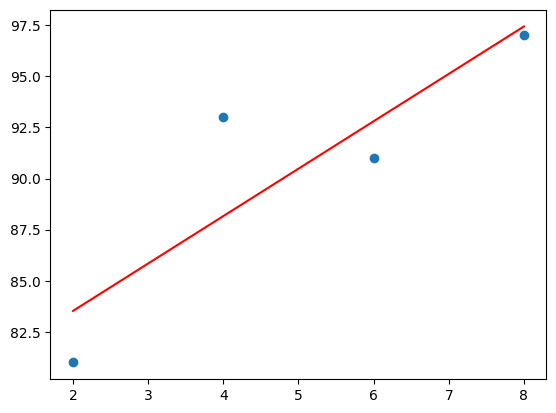

In [10]:
plt.scatter(x, y)
plt.plot(x, model.predict(x),'r')    # 예측 결과를 그래프로 나타냅니다.
plt.show()

### 5. 모델 테스트

In [12]:
#임의의 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.

hour = 7
prediction = model.predict([hour])

print("%.f시간을 공부할 경우의 예상 점수는 %.02f점입니다" % (hour, prediction))

ValueError: Unrecognized data type: x=[7] (of type <class 'list'>)

## 5-2 텐서플로에서 실행하는 다중 선형회귀 모델

### 1.환경 준비

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [ ]:
x = np.array([[2, 0], [4, 4], [6, 2], [8, 3]])
y = np.array([81, 93, 91, 97]) 

### 3. 모델 실행

In [ ]:
model = Sequential()

#입력 변수가 2개(학습 시간, 과외 시간)이므로 input_dim에 2를 입력합니다. 
model.add(Dense(1, input_dim=2, activation='linear'))
model.compile(optimizer='sgd' ,loss='mse')

model.fit(x, y, epochs=2000)

Epoch 1/2000
1/1 [==============================] - 0s 119ms/step - loss: 8184.9204
Epoch 2/2000
1/1 [==============================] - 0s 2ms/step - loss: 1435.6133
Epoch 3/2000
1/1 [==============================] - 0s 999us/step - loss: 955.4879
Epoch 4/2000
1/1 [==============================] - 0s 1ms/step - loss: 916.3068
Epoch 5/2000
1/1 [==============================] - 0s 2ms/step - loss: 908.1718
Epoch 6/2000
1/1 [==============================] - 0s 1ms/step - loss: 902.2542
Epoch 7/2000
1/1 [==============================] - 0s 2ms/step - loss: 896.5266
Epoch 8/2000
1/1 [==============================] - 0s 2ms/step - loss: 890.8461
Epoch 9/2000
1/1 [==============================] - 0s 2ms/step - loss: 885.2023
Epoch 10/2000
1/1 [==============================] - 0s 1ms/step - loss: 879.5942
Epoch 11/2000
1/1 [==============================] - 0s 1ms/step - loss: 874.0219
Epoch 12/2000
1/1 [==============================] - 0s 2ms/step - loss: 868.4847
Epoch 13/2000
1/1 [

1/1 [==============================] - 0s 1ms/step - loss: 266.3661
Epoch 199/2000
1/1 [==============================] - 0s 2ms/step - loss: 264.6792
Epoch 200/2000
1/1 [==============================] - 0s 1ms/step - loss: 263.0029
Epoch 201/2000
1/1 [==============================] - 0s 999us/step - loss: 261.3373
Epoch 202/2000
1/1 [==============================] - 0s 2ms/step - loss: 259.6821
Epoch 203/2000
1/1 [==============================] - 0s 1ms/step - loss: 258.0376
Epoch 204/2000
1/1 [==============================] - 0s 1ms/step - loss: 256.4033
Epoch 205/2000
1/1 [==============================] - 0s 1ms/step - loss: 254.7795
Epoch 206/2000
1/1 [==============================] - 0s 1ms/step - loss: 253.1659
Epoch 207/2000
1/1 [==============================] - 0s 1ms/step - loss: 251.5626
Epoch 208/2000
1/1 [==============================] - 0s 1ms/step - loss: 249.9693
Epoch 209/2000
1/1 [==============================] - 0s 1000us/step - loss: 248.3863
Epoch 210/2000

1/1 [==============================] - 0s 1ms/step - loss: 76.7026
Epoch 395/2000
1/1 [==============================] - 0s 999us/step - loss: 76.2172
Epoch 396/2000
1/1 [==============================] - 0s 999us/step - loss: 75.7348
Epoch 397/2000
1/1 [==============================] - 0s 1000us/step - loss: 75.2555
Epoch 398/2000
1/1 [==============================] - 0s 2ms/step - loss: 74.7792
Epoch 399/2000
1/1 [==============================] - 0s 1ms/step - loss: 74.3059
Epoch 400/2000
1/1 [==============================] - 0s 2ms/step - loss: 73.8356
Epoch 401/2000
1/1 [==============================] - 0s 1ms/step - loss: 73.3683
Epoch 402/2000
1/1 [==============================] - 0s 1000us/step - loss: 72.9040
Epoch 403/2000
1/1 [==============================] - 0s 998us/step - loss: 72.4426
Epoch 404/2000
1/1 [==============================] - 0s 2ms/step - loss: 71.9841
Epoch 405/2000
1/1 [==============================] - 0s 1ms/step - loss: 71.5285
Epoch 406/2000
1/1 

1/1 [==============================] - 0s 2ms/step - loss: 21.8449
Epoch 593/2000
1/1 [==============================] - 0s 1ms/step - loss: 21.7070
Epoch 594/2000
1/1 [==============================] - 0s 1ms/step - loss: 21.5699
Epoch 595/2000
1/1 [==============================] - 0s 1000us/step - loss: 21.4337
Epoch 596/2000
1/1 [==============================] - 0s 1ms/step - loss: 21.2984
Epoch 597/2000
1/1 [==============================] - 0s 1ms/step - loss: 21.1640
Epoch 598/2000
1/1 [==============================] - 0s 2ms/step - loss: 21.0303
Epoch 599/2000
1/1 [==============================] - 0s 2ms/step - loss: 20.8976
Epoch 600/2000
1/1 [==============================] - 0s 998us/step - loss: 20.7656
Epoch 601/2000
1/1 [==============================] - 0s 1000us/step - loss: 20.6345
Epoch 602/2000
1/1 [==============================] - 0s 1ms/step - loss: 20.5043
Epoch 603/2000
1/1 [==============================] - 0s 1ms/step - loss: 20.3748
Epoch 604/2000
1/1 [===

1/1 [==============================] - 0s 2ms/step - loss: 6.2189
Epoch 792/2000
1/1 [==============================] - 0s 1000us/step - loss: 6.1800
Epoch 793/2000
1/1 [==============================] - 0s 1000us/step - loss: 6.1413
Epoch 794/2000
1/1 [==============================] - 0s 3ms/step - loss: 6.1028
Epoch 795/2000
1/1 [==============================] - 0s 3ms/step - loss: 6.0646
Epoch 796/2000
1/1 [==============================] - 0s 1ms/step - loss: 6.0267
Epoch 797/2000
1/1 [==============================] - 0s 1ms/step - loss: 5.9890
Epoch 798/2000
1/1 [==============================] - 0s 2ms/step - loss: 5.9515
Epoch 799/2000
1/1 [==============================] - 0s 2ms/step - loss: 5.9142
Epoch 800/2000
1/1 [==============================] - 0s 3ms/step - loss: 5.8772
Epoch 801/2000
1/1 [==============================] - 0s 999us/step - loss: 5.8404
Epoch 802/2000
1/1 [==============================] - 0s 1ms/step - loss: 5.8039
Epoch 803/2000
1/1 [===============

...

1/1 [==============================] - 0s 1ms/step - loss: 0.5615
Epoch 1190/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.5584
Epoch 1191/2000
1/1 [==============================] - 0s 999us/step - loss: 0.5553
Epoch 1192/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.5522
Epoch 1193/2000
1/1 [==============================] - 0s 999us/step - loss: 0.5492
Epoch 1194/2000
1/1 [==============================] - 0s 997us/step - loss: 0.5461
Epoch 1195/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.5431
Epoch 1196/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.5401
Epoch 1197/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.5372
Epoch 1198/2000
1/1 [==============================] - 0s 1000us/step - loss: 0.5342
Epoch 1199/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.5313
Epoch 1200/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.5284
Epoch 1201/2000
1/1 [==

1/1 [==============================] - 0s 2ms/step - loss: 0.2107
Epoch 1388/2000
1/1 [==============================] - 0s 999us/step - loss: 0.2098
Epoch 1389/2000
1/1 [==============================] - 0s 998us/step - loss: 0.2089
Epoch 1390/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.2080
Epoch 1391/2000
1/1 [==============================] - 0s 996us/step - loss: 0.2072
Epoch 1392/2000
1/1 [==============================] - 0s 999us/step - loss: 0.2063
Epoch 1393/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.2055
Epoch 1394/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.2046
Epoch 1395/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.2038
Epoch 1396/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.2029
Epoch 1397/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.2021
Epoch 1398/2000
1/1 [==============================] - 0s 997us/step - loss: 0.2013
Epoch 1399/2000
1/1 [=

1/1 [==============================] - 0s 1ms/step - loss: 0.1110
Epoch 1586/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.1107
Epoch 1587/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.1105
Epoch 1588/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.1102
Epoch 1589/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.1100
Epoch 1590/2000
1/1 [==============================] - 0s 997us/step - loss: 0.1098
Epoch 1591/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.1095
Epoch 1592/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.1093
Epoch 1593/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.1090
Epoch 1594/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.1088
Epoch 1595/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.1086
Epoch 1596/2000
1/1 [==============================] - 0s 998us/step - loss: 0.1083
Epoch 1597/2000
1/1 [=======

1/1 [==============================] - 0s 1ms/step - loss: 0.0827
Epoch 1784/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0826
Epoch 1785/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0825
Epoch 1786/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0825
Epoch 1787/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0824
Epoch 1788/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0823
Epoch 1789/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0823
Epoch 1790/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.0822
Epoch 1791/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0821
Epoch 1792/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0820
Epoch 1793/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.0820
Epoch 1794/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0819
Epoch 1795/2000
1/1 [===========

1/1 [==============================] - 0s 1ms/step - loss: 0.0746
Epoch 1982/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0746
Epoch 1983/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.0746
Epoch 1984/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0746
Epoch 1985/2000
1/1 [==============================] - 0s 1000us/step - loss: 0.0745
Epoch 1986/2000
1/1 [==============================] - 0s 999us/step - loss: 0.0745
Epoch 1987/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0745
Epoch 1988/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0745
Epoch 1989/2000
1/1 [==============================] - 0s 2ms/step - loss: 0.0745
Epoch 1990/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0744
Epoch 1991/2000
1/1 [==============================] - 0s 1000us/step - loss: 0.0744
Epoch 1992/2000
1/1 [==============================] - 0s 1ms/step - loss: 0.0744
Epoch 1993/2000
1/1 [===

### 4. 모델 테스트

In [ ]:
#임의의 학습 시간과 과외 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.

hour = 7
private_class = 4
prediction = model.predict([[hour, private_class]])

print("%.f시간을 공부하고 %.f시간의 과외를 받을 경우, 예상 점수는 %.02f점입니다" % (hour, private_class, prediction))

7시간을 공부하고 4시간의 과외를 받을 경우, 예상 점수는 97.53점입니다
